# 🟠 สมุดบันทึกที่ 3: การสร้างและประเมินผลโมเดล Naive Bayes (คนที่ 2)
**วิชา:** การทำเหมืองข้อมูล (Data Mining)  
**เนื้อหาอ้างอิง:** บทที่ 6 การจำแนกประเภท (ต่อ): K-Nearest Neighbors (KNN) และ Naive Bayes  
**ผู้รับผิดชอบ:** คนที่ 2 (Naive Bayes Specialist)  
**เป้าหมาย:** เลือกชนิด Naive Bayes ให้เหมาะสมกับลักษณะข้อมูล พร้อมให้เหตุผลทางทฤษฎี, เทรนโมเดล, วิเคราะห์หา Feature ที่ส่งผลต่อการทำนาย, และประเมินผลประสิทธิภาพ


## 1. การเลือกชนิดของ Naive Bayes (หัวใจสำคัญตามโจทย์)
ตามบทที่ 6.2.5 ของอาจารย์ มี Naive Bayes หลักๆ 3 ประเภท:
1. **Gaussian NB:** เหมาะกับแอตทริบิวต์ต่อเนื่อง (Continuous) ที่มีการแจกแจงแบบปกติ (Normal Distribution)
2. **Multinomial NB:** เหมาะกับข้อมูลนับความถี่ (Word Count / Text Classification)
3. **Bernoulli NB / Categorical NB:** เหมาะกับข้อมูลแบบ Binary หรือ หมวดหมู่ที่ไม่ต่อเนื่อง

### 💡 เหตุผลในการเลือกใช้ `GaussianNB`:
* ชุดข้อมูลมีตัวแปรตัวเลขต่อเนื่องสำคัญ ได้แก่ `absences` (จำนวนวันขาดเรียน 0-32 วัน) และ `age` (อายุ 15-22 ปี)
* หากใช้ `CategoricalNB` ตรงๆ จะเกิดปัญหา **Index Out of Bounds Error** เมื่อชุดทดสอบมีค่าตัวเลขที่ชุดฝึกสอนไม่เคยพบ (Unseen Values)
* ในทางปฏิบัติของ Scikit-learn การใช้ `GaussianNB` บนเวกเตอร์ตัวเลขและตัวแปร One-Hot Encoding เป็นวิธีที่เสถียรที่สุด ไม่ต้องเสียเวลาทำ Binning และไม่พังเมื่อเจอตัวเลขใหม่


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# โหลดชุดข้อมูลที่เตรียมไว้จาก Notebook 1
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop(columns=['passed'])
y_train = train_df['passed']
X_test = test_df.drop(columns=['passed'])
y_test = test_df['passed']

print(f"📦 โหลดข้อมูลสำเร็จ: X_train = {X_train.shape}, X_test = {X_test.shape}")


📦 โหลดข้อมูลสำเร็จ: X_train = (519, 39), X_test = (130, 39)


## 2. การเทรนโมเดล Gaussian Naive Bayes


In [22]:
# สร้างและฝึกสอนโมเดล GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

train_acc = gnb.score(X_train, y_train)
test_acc = gnb.score(X_test, y_test)

print("=" * 60)
print("🟠 ผลการประเมินเบื้องต้นของ Gaussian Naive Bayes:")
print("=" * 60)
print(f"• Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"• Testing Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")


🟠 ผลการประเมินเบื้องต้นของ Gaussian Naive Bayes:
• Training Accuracy : 0.7765 (77.65%)
• Testing Accuracy  : 0.6385 (63.85%)


## 3. การวิเคราะห์หา Feature ที่ส่งผลต่อการทำนาย
เนื่องจาก Naive Bayes ไม่มี `feature_importances_` ในตัวเหมือน Decision Tree เราจึงใช้วิธีตามหลักวิทยาศาสตร์ 2 วิธี:
1. **Permutation Feature Importance:** สลับค่าข้อมูลทีละคอลัมน์แล้วดูว่าค่าความแม่นยำตกไปเท่าไหร่
2. **Class Mean Difference ($\theta$):** เปรียบเทียบค่าเฉลี่ยของแต่ละตัวแปรระหว่างกลุ่มผ่าน vs กลุ่มตก


In [23]:
# วิธีที่ 1: Permutation Importance
perm = permutation_importance(gnb, X_test, y_test, n_repeats=10, random_state=42)
nb_importance = pd.Series(perm.importances_mean, index=X_train.columns).sort_values(ascending=False)

print("📌 Top 5 Features (Permutation Importance):")
print("-" * 50)
print(nb_importance.head(5))

# วิธีที่ 2: วิเคราะห์ค่า Mean (Theta) แยกตามคลาส Pass (1) vs Fail (0)
theta_df = pd.DataFrame(gnb.theta_, index=['Fail (0)', 'Pass (1)'], columns=X_train.columns)
mean_diff = (theta_df.loc['Pass (1)'] - theta_df.loc['Fail (0)']).abs().sort_values(ascending=False)
print("\n📌 Top 5 Features ที่มีค่าเฉลี่ยต่างกันมากที่สุดระหว่าง Pass กับ Fail:")
print("-" * 50)
print(mean_diff.head(5))


📌 Top 5 Features (Permutation Importance):
--------------------------------------------------
higher_yes     0.036154
failures       0.027692
studytime      0.012308
Walc           0.012308
famsize_LE3    0.012308
dtype: float64

📌 Top 5 Features ที่มีค่าเฉลี่ยต่างกันมากที่สุดระหว่าง Pass กับ Fail:
--------------------------------------------------
absences    1.432090
failures    0.719049
Medu        0.638867
Fedu        0.508798
Walc        0.469989
dtype: float64


## 4. การประเมินผลผ่าน Confusion Matrix และ Metrics


📊 Confusion Matrix (Naive Bayes):
[[10 10]
 [37 73]]


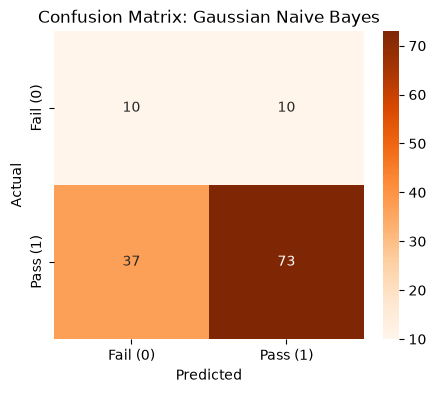


📋 Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.21      0.50      0.30        20
    Pass (1)       0.88      0.66      0.76       110

    accuracy                           0.64       130
   macro avg       0.55      0.58      0.53       130
weighted avg       0.78      0.64      0.69       130



In [24]:
y_pred_nb = gnb.predict(X_test)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("📊 Confusion Matrix (Naive Bayes):")
print(cm_nb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fail (0)', 'Pass (1)'],
            yticklabels=['Fail (0)', 'Pass (1)'])
plt.title('Confusion Matrix: Gaussian Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Fail (0)', 'Pass (1)']))


### 💡 ประเด็นอภิปรายของ Gaussian Naive Bayes (จากผลที่รันจริง)
* Test Accuracy = **63.85%**, Macro F1 = **0.53**
* จับเด็กตกได้ **10 จาก 20 คน (Recall (Fail) = 50%)** แต่ทายว่า "ตก" ทั้งหมด 47 คน ซึ่งตกจริงแค่ 10 คน (**Precision (Fail) = 0.21**) แปลว่าครูต้องเรียกคุยนักเรียน 47 คนเพื่อเจอเด็กกลุ่มเสี่ยงจริง 10 คน
* **ข้อสันนิษฐาน:** Accuracy ต่ำอาจเกิดจากการใช้ GaussianNB (ซึ่งสมมติว่าข้อมูลเป็นรูประฆังคว่ำ) กับข้อมูล One-Hot ที่มีแค่ 0/1 และกับ `absences` ที่เบ้ขวามาก → ทดสอบข้อสันนิษฐานนี้ใน Section 5 ด้วย CategoricalNB
* **ข้อจำกัด:** Permutation Importance คำนวณบน test set เพียง 130 คน ค่า 0.0123 เท่ากับทายเปลี่ยนไปแค่ 1–2 คน ผลจึงแกว่งได้สูง

## 5. การทดลองเสริม: Discretization + CategoricalNB
**แนวคิด:** CategoricalNB คำนวณ $P(x_i|C)$ จากการ**นับความถี่ของแต่ละหมวดหมู่**ตรงตามทฤษฎี Bayes (บทที่ 6) แต่ต้องการข้อมูลที่เป็นหมวดหมู่ทุกคอลัมน์ เราจึงต้อง
1. ดึงข้อมูลดิบ (ก่อน One-Hot) ของนักเรียน**ชุดเดิม**กลับมา
2. แบ่งช่วง (Discretization, บทที่ 2) ให้ตัวแปรตัวเลข `age` และ `absences`
3. แปลงเป็นเลขหมวดหมู่ด้วย `OrdinalEncoder` แล้วเทรน CategoricalNB

### 5.1 ดึงแถวเดิมกลับมาจากข้อมูลดิบ
`train_test_split` เลือกแถวจากจำนวนแถว, `y`, `test_size`, `random_state` และ `stratify` เท่านั้น ถ้าใช้ค่าเดิมกับ Notebook 1 ทุกตัว จะได้นักเรียนชุดเดียวกับ `train.csv` / `test.csv`

In [25]:
from sklearn.model_selection import train_test_split

# โหลดข้อมูลดิบ (path และวิธีอ่านเหมือน Notebook 1)
raw = pd.read_csv('../data/student-por.csv', sep=';')
if raw.shape[1] == 1:
    raw = pd.read_csv('../data/student-por.csv', sep=',')

raw['passed'] = (raw['G3'] >= 10).astype(int)
X_raw = raw.drop(columns=['G1', 'G2', 'G3', 'passed'])
y_raw = raw['passed']

# แบ่งด้วยพารามิเตอร์เดียวกับ Notebook 1 ทุกตัว
X_train_raw, X_test_raw, y_train_c, y_test_c = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

# ตรวจสอบว่าเป็นนักเรียนชุดเดียวกับ test.csv (ต้องได้ True ทั้งคู่)
print("age ตรงกัน   :", (X_test_raw['age'].values == X_test['age'].values).all())
print("label ตรงกัน :", (y_test_c.values == y_test.values).all())

age ตรงกัน   : True
label ตรงกัน : True


### 5.2 สำรวจการกระจายตัวของ `absences` และ `age` (ใช้ train set เท่านั้น)

📊 Quantile ของ absences (train set):
0.25     0.0
0.50     2.0
0.75     6.0
0.90    10.0
Name: absences, dtype: float64


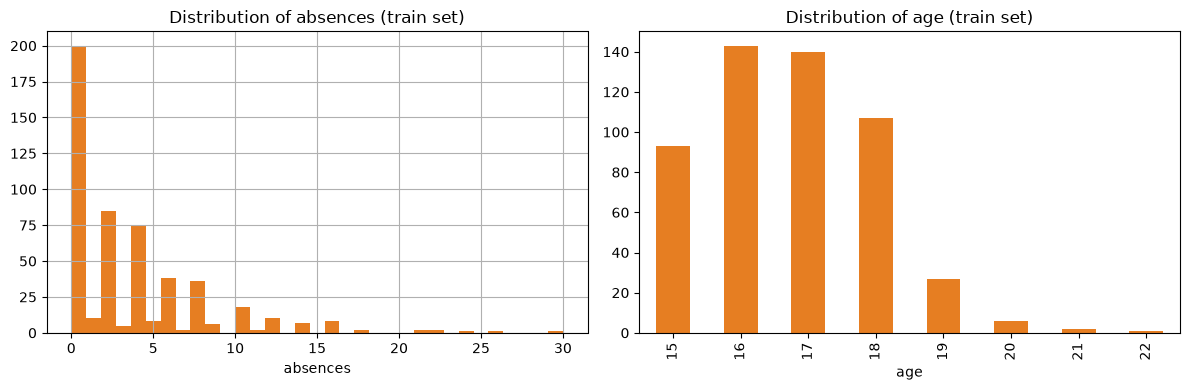

In [26]:
print("📊 Quantile ของ absences (train set):")
print(X_train_raw['absences'].quantile([0.25, 0.5, 0.75, 0.9]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
X_train_raw['absences'].hist(bins=33, ax=axes[0], color='#e67e22')
axes[0].set_title('Distribution of absences (train set)')
axes[0].set_xlabel('absences')
X_train_raw['age'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#e67e22')
axes[1].set_title('Distribution of age (train set)')
plt.tight_layout()
plt.show()

### 5.3 Discretization ด้วย `pd.cut`
**เหตุผลของจุดแบ่ง:**
* `absences`: **0–2** (ไม่เกินค่ากลาง Q2), **3–6** (ถึง Q3), **7–15** (สูงกว่า Q3 แต่ยังไม่เกิน Upper Bound ของ IQR = 15 จาก Notebook 1), **>15** (กลุ่ม Outlier ที่ขาดเรียนหนัก)
* `age`: **15–16**, **17–18** (อายุปกติของนักเรียนมัธยมปลาย), **>18** (อายุเกินเกณฑ์ ซึ่งมักสัมพันธ์กับการเคยซ้ำชั้น)
* ช่วงบนสุดใช้ `np.inf` เพื่อให้ครอบคลุมค่าใน test set ทุกค่า

In [27]:
def discretize(df):
    df = df.copy()
    df['absences'] = pd.cut(df['absences'], bins=[-1, 2, 6, 15, np.inf],
                            labels=['0-2', '3-6', '7-15', '>15'])
    df['age'] = pd.cut(df['age'], bins=[-np.inf, 16, 18, np.inf],
                       labels=['15-16', '17-18', '>18'])
    return df

X_train_cat = discretize(X_train_raw)
X_test_cat = discretize(X_test_raw)

print("จำนวนนักเรียนแต่ละช่วง (train set):")
print(X_train_cat['absences'].value_counts().sort_index(), "\n")
print(X_train_cat['age'].value_counts().sort_index())

จำนวนนักเรียนแต่ละช่วง (train set):
absences
0-2     295
3-6     126
7-15     81
>15      17
Name: count, dtype: int64 

age
15-16    236
17-18    247
>18       36
Name: count, dtype: int64


### 5.4 แปลงเป็นเลขหมวดหมู่และเทรน CategoricalNB
* `OrdinalEncoder` เรียนแค่**รายชื่อหมวดหมู่**ของแต่ละคอลัมน์ (ไม่ได้ดูผลสอบ) จึงไม่ถือเป็น Data Leakage
* `min_categories` บอกจำนวนหมวดของแต่ละคอลัมน์ล่วงหน้า กัน Error เมื่อ test set มีหมวดที่ train ไม่เคยเจอ
* `alpha=1.0` คือ **Laplace Smoothing** แก้ปัญหา Zero Probability (บทที่ 6)

In [28]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

enc = OrdinalEncoder()
enc.fit(pd.concat([X_train_cat, X_test_cat]).astype(str))
Xtr_enc = enc.transform(X_train_cat.astype(str))
Xte_enc = enc.transform(X_test_cat.astype(str))

n_cats = [len(c) for c in enc.categories_]
cnb = CategoricalNB(alpha=1.0, min_categories=n_cats)
cnb.fit(Xtr_enc, y_train_c)

print("=" * 60)
print("🟣 ผลการประเมินเบื้องต้นของ Categorical Naive Bayes:")
print("=" * 60)
print(f"• Training Accuracy : {cnb.score(Xtr_enc, y_train_c):.4f}")
print(f"• Testing Accuracy  : {cnb.score(Xte_enc, y_test_c):.4f}")

🟣 ผลการประเมินเบื้องต้นของ Categorical Naive Bayes:
• Training Accuracy : 0.8613
• Testing Accuracy  : 0.7692


📊 Confusion Matrix (Categorical NB):
[[ 6 14]
 [16 94]]


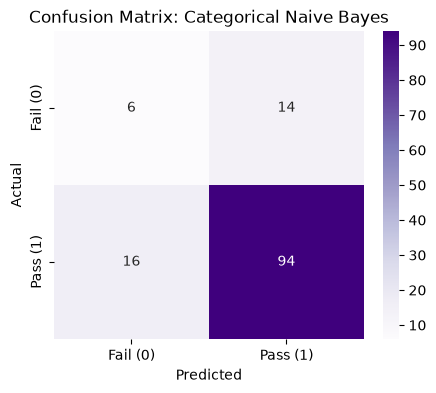


📋 Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.27      0.30      0.29        20
    Pass (1)       0.87      0.85      0.86       110

    accuracy                           0.77       130
   macro avg       0.57      0.58      0.57       130
weighted avg       0.78      0.77      0.77       130



In [29]:
y_pred_cnb = cnb.predict(Xte_enc)
cm_cnb = confusion_matrix(y_test_c, y_pred_cnb)

print("📊 Confusion Matrix (Categorical NB):")
print(cm_cnb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Fail (0)', 'Pass (1)'],
            yticklabels=['Fail (0)', 'Pass (1)'])
plt.title('Confusion Matrix: Categorical Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_test_c, y_pred_cnb, target_names=['Fail (0)', 'Pass (1)']))

## 6. เปรียบเทียบ GaussianNB vs CategoricalNB

In [30]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Fail)": precision_score(y_true, y_pred, pos_label=0),
        "Recall (Fail)": recall_score(y_true, y_pred, pos_label=0),
        "F1 (Macro)": f1_score(y_true, y_pred, average='macro'),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

nb_compare = pd.DataFrame([
    evaluate("Gaussian NB", y_test, y_pred_nb, gnb.predict_proba(X_test)[:, 1]),
    evaluate("Categorical NB", y_test_c, y_pred_cnb, cnb.predict_proba(Xte_enc)[:, 1]),
]).set_index("Model").round(4)

nb_compare

,Accuracy,Precision (Fail),Recall (Fail),F1 (Macro),ROC-AUC
Model,,,,,
Gaussian NB,0.6385,0.2128,0.5,0.5275,0.5023
Categorical NB,0.7692,0.2727,0.3,0.5740,0.5905


### 💡 อภิปรายผลการเปรียบเทียบ (เขียนจากผลที่รันได้จริง)
*TODO: ตอบคำถามต่อไปนี้หลังรันเสร็จ*
1. CategoricalNB ดีขึ้นหรือแย่ลงใน metric ไหนบ้าง? สนับสนุนข้อสันนิษฐานใน Section 4 หรือไม่?
2. ถ้า Accuracy กับ Recall (Fail) ไปคนละทิศทาง สำหรับระบบเตือนภัยนักเรียนกลุ่มเสี่ยง ควรเลือกโมเดลไหน เพราะอะไร?
3. ข้อจำกัด: test set มีนักเรียนตกแค่ 20 คน ต่างกัน 1 คน = Recall ต่างกัน 5%